In [2]:
import numpy as np
import matplotlib.pyplot as plt

In [3]:
m = 50
n = 32

In [4]:
def fjk(j, k):
    return (k+1) / np.sqrt(m) * np.exp(2 * np.pi * 1j * j * k / m)
v = np.arange(1, n + 1)

In [5]:
T = np.fromfunction(fjk, (32, 50))
S = T @ T.conjugate().T

In [6]:
def get_bounds(T):
    svdvals = np.linalg.svdvals(T)
    return svdvals[-1] ** 2, svdvals[0] ** 2

In [7]:
def get_decomposition(T, f):
    return np.linalg.pinv(T) @ f

# Задача 2.2. Границы фрейма

In [8]:
bounds = get_bounds(T)
A, B = bounds
print("Frame bounds:")
bounds

Frame bounds:


(np.float64(7.375000124181121), np.float64(2392.9956154058996))

# Задача 2.3. Разложение по фрейму

In [9]:
decomp = get_decomposition(T, v)
print("Exact frame decomposition:")
decomp

Exact frame decomposition:


array([ 2.05036512-1.18636257e+00j, -7.33464896-5.09242198e+00j,
       -1.25297325+8.55823414e+00j, -1.19483066-5.20429149e-01j,
        2.14815314+3.13263115e+00j, -1.56211634+1.42688580e+00j,
        1.48312228+9.83215930e-02j,  0.12472113+2.32344046e+00j,
       -0.47315812-9.51546115e-02j,  1.25909009+9.53012994e-01j,
       -0.63778451+1.28403769e+00j,  0.26286426-2.25290041e-01j,
        0.58146049+1.29751214e+00j, -0.73673048+4.87937818e-01j,
        0.58888321+8.82539423e-02j, -0.07667629+1.23882642e+00j,
       -0.51571216+4.99299173e-03j,  0.56813097+4.87505941e-01j,
       -0.55214617+9.22614329e-01j, -0.19147146-1.77775738e-01j,
        0.29704456+7.91211218e-01j, -0.78943155+4.88551355e-01j,
        0.08723726-1.18730467e-01j, -0.11178569+9.06931762e-01j,
       -0.79655688+5.81999827e-02j,  0.2256866 +9.32210723e-02j,
       -0.54455647+8.04930802e-01j, -0.62509355-2.76690352e-01j,
        0.18011688+3.53990262e-01j, -0.90134663+5.03037736e-01j,
       -0.35200802-4.6333

# Задача 2.4. Фреймовый алгоритм

In [10]:
err = np.inf
fn = np.zeros_like(v, dtype=np.complex128)
c = T.conjugate().T @ v
n = 1
Sf = T @ c
errors_frame_alg = []
while np.abs(err) > 1e-11:
    fn += 2 / (A + B) * (Sf - S @ fn)
    err = np.power((B - A) / (B + A), n) * np.linalg.norm(fn) #
    true_err = np.linalg.norm(fn - v)
    errors_frame_alg.append(true_err)
    n += 1

In [11]:
print("Reconstructed v:")
fn

Reconstructed v:


array([ 1.-5.85503660e-15j,  2.+7.29344293e-14j,  3.+2.01117715e-13j,
        4.+3.27387137e-13j,  5.+4.32769861e-13j,  6.+5.23265610e-13j,
        7.+5.93490439e-13j,  8.+6.50484666e-13j,  9.+6.82984439e-13j,
       10.+6.85480110e-13j, 11.+6.58785221e-13j, 12.+6.07577186e-13j,
       13.+5.44853681e-13j, 14.+4.58001195e-13j, 15.+3.74086544e-13j,
       16.+2.78422391e-13j, 17.+1.77632827e-13j, 18.+5.55112577e-14j,
       19.-5.44173845e-14j, 20.-1.62741856e-13j, 21.-2.56985372e-13j,
       22.-3.05610033e-13j, 23.-3.14723980e-13j, 24.-3.22376950e-13j,
       25.-3.33313087e-13j, 26.-3.29065156e-13j, 27.-2.94047934e-13j,
       28.-2.34299605e-13j, 29.-1.91486192e-13j, 30.-1.52161660e-13j,
       31.-6.12990967e-14j, 32.+1.37820749e-14j])

# Задача 3. Метод сопряжённых градиентов для ускорения фреймового алгоритма

In [12]:
def ip(a, b):
    return np.vdot(b, a)

In [14]:
c = T.conjugate().T @ v
r = T @ c
p = r.copy()
Sp = S @ p
x = np.zeros_like(p)
errors_cg = []
norm = np.linalg.norm(x - v)
λ = ip(r, p) / ip(p, Sp)
x += λ * p
errors_cg.append(norm)
r -= λ * Sp
p_new = Sp - (ip(Sp, Sp) / ip(p, Sp)) * p
p_old = p
Spold = Sp
p = p_new
num_iter = 3600
for it in range(num_iter):
    norm = np.linalg.norm(x - v)
    errors_cg.append(norm)

    Sp = S @ p
    λ = ip(r, p) / ip(p, Sp)
    x += λ * p
    r -= λ * Sp
    if np.linalg.norm(r) < 1e-11:
        errors_cg.append(np.linalg.norm(x - v))
        break

    p_new = Sp - (ip(Sp, Sp) / ip(p, Sp)) * p - (ip(Sp, Spold) / ip(p_old, Spold)) * p_old
    p_old = p
    Spold = Sp
    p = p_new

In [15]:
print("Reconstructed v:")
x

Reconstructed v:


array([ 1.+3.27402585e-14j,  2.+5.19940141e-14j,  3.+6.15493455e-14j,
        4.+5.71348624e-14j,  5.+4.38925625e-14j,  6.+3.76913080e-14j,
        7.+1.82748429e-14j,  8.+1.91471326e-14j,  9.+3.43732900e-14j,
       10.+4.79185262e-14j, 11.+4.62566811e-14j, 12.+4.17969980e-14j,
       13.+5.12812241e-14j, 14.+3.20607131e-14j, 15.+3.03511101e-14j,
       16.+1.33324055e-14j, 17.+9.94032551e-15j, 18.-1.71163410e-14j,
       19.-4.43028550e-14j, 20.-9.63158500e-14j, 21.-1.26971401e-13j,
       22.-1.29150431e-13j, 23.-1.20033594e-13j, 24.-1.24282309e-13j,
       25.-1.43850135e-13j, 26.-1.45093225e-13j, 27.-1.29400837e-13j,
       28.-1.01821388e-13j, 29.-1.01997618e-13j, 30.-9.06931806e-14j,
       31.-3.09008296e-14j, 32.+2.28589259e-14j])

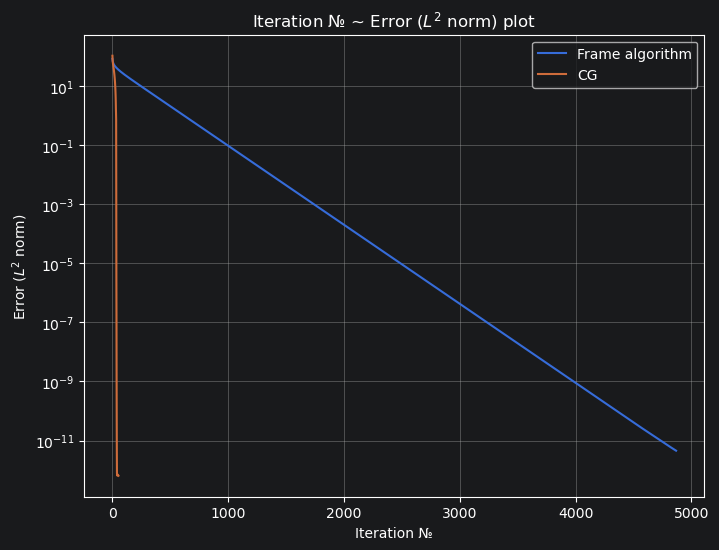

In [16]:
plt.figure(figsize=(8,6))
plt.xlabel("Iteration №")
plt.ylabel("Error ($L^2$ norm)")
plt.grid(True)
plt.semilogy(errors_frame_alg, label='Frame algorithm')
plt.semilogy(errors_cg, label='CG')
plt.title("Iteration № ~ Error ($L^2$ norm) plot")
plt.legend()
plt.show()

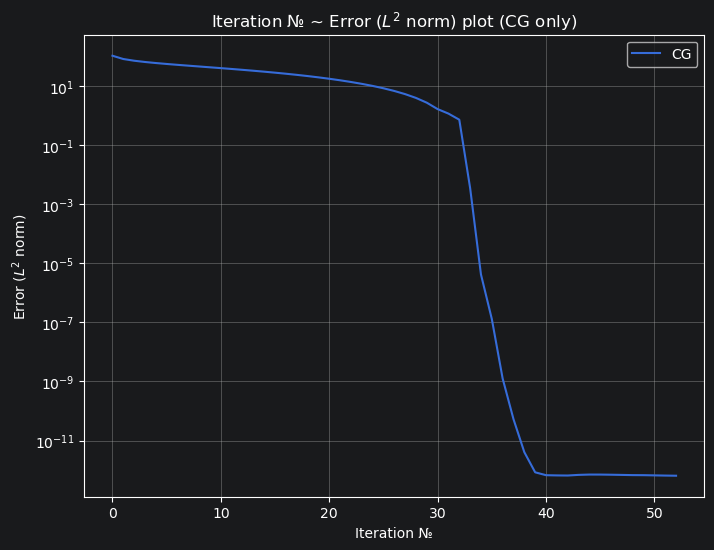

In [17]:
plt.figure(figsize=(8,6))
plt.xlabel("Iteration №")
plt.ylabel("Error ($L^2$ norm)")
plt.grid(True)
plt.semilogy(errors_cg, label='CG')
plt.title("Iteration № ~ Error ($L^2$ norm) plot (CG only)")
plt.legend()
plt.show()

# Альтернативные версии метода сопряжённых градиентов для фреймового алгоритма

## Альтернативная версия алгоритма (с двумя слагаемыми в формуле для $p_n$)

In [18]:
# reformulated two-term p_n version from the paper
c = T.conjugate().T @ v
r = T @ c
p = r.copy()
Sp = S @ p
x = np.zeros_like(p)
errors_cg_two = []
num_iter = 3600

for it in range(num_iter):
    norm = np.linalg.norm(x - v)
    errors_cg_two.append(norm)

    Sp = S @ p
    λ = ip(r, p) / ip(p, Sp)
    x += λ * p
    r -= λ * Sp
    if np.linalg.norm(r) < 1e-11:
        errors_cg_two.append(np.linalg.norm(x - v))
        break

    p_new = r - (ip(r, Sp) / ip(p, Sp)) * p
    p = p_new

In [19]:
print("Reconstructed v:")
x

Reconstructed v:


array([ 1.-2.50725743e-16j,  2.-1.67711838e-14j,  3.-1.55149186e-14j,
        4.+7.65529451e-15j,  5.+2.37789405e-14j,  6.+3.17474673e-14j,
        7.+3.10498839e-14j,  8.+5.44786973e-14j,  9.+7.18328034e-14j,
       10.+8.67988222e-14j, 11.+8.81476119e-14j, 12.+8.49655680e-14j,
       13.+9.48169044e-14j, 14.+9.15044537e-14j, 15.+8.96549325e-14j,
       16.+8.17017213e-14j, 17.+7.64371087e-14j, 18.+4.27338880e-14j,
       19.+1.46177994e-15j, 20.-5.41871298e-14j, 21.-8.95736066e-14j,
       22.-8.88907446e-14j, 23.-7.09403638e-14j, 24.-6.57569798e-14j,
       25.-6.00677386e-14j, 26.-4.87805704e-14j, 27.-2.21417477e-14j,
       28.+9.50242872e-16j, 29.-2.19421448e-14j, 30.-4.41024439e-14j,
       31.-2.74542266e-14j, 32.-5.49501762e-15j])

## Применение классической формулировки метода сопряжённых градиентов для разложения по фрейму

In [20]:
# classic version of CG for linear equations
r = T @ c
p = r.copy()
x = np.zeros_like(v, dtype=np.complex128)
errors_cg_classic = []
num_iter = 3600

for it in range(num_iter):
    norm = np.linalg.norm(x - v)
    errors_cg_classic.append(norm)

    Sp = S @ p
    alpha = ip(r, r) / ip(p, Sp)

    x_new = x + alpha * p
    r_new = r - alpha * Sp

    if np.linalg.norm(r_new) < 1e-11:
        x = x_new
        errors_cg_classic.append(np.linalg.norm(x-v))
        break


    beta = ip(r_new, r_new) / ip(r, r)

    p = r_new + beta * p
    x = x_new
    r = r_new

In [21]:
print("Reconstructed v:")
x

Reconstructed v:


array([ 1.-1.09288312e-16j,  2.+3.67618457e-16j,  3.-1.09496198e-14j,
        4.+6.51519518e-15j,  5.+2.64230572e-14j,  6.+3.58641459e-14j,
        7.+3.78310263e-14j,  8.+6.20923959e-14j,  9.+7.79290871e-14j,
       10.+8.82507929e-14j, 11.+8.31035665e-14j, 12.+7.58640221e-14j,
       13.+7.92382080e-14j, 14.+6.83153862e-14j, 15.+6.35675022e-14j,
       16.+5.59314155e-14j, 17.+4.48362135e-14j, 18.+7.68706874e-15j,
       19.-3.23159307e-14j, 20.-8.32855199e-14j, 21.-1.08200745e-13j,
       22.-1.04769122e-13j, 23.-8.34312037e-14j, 24.-7.45434674e-14j,
       25.-6.71686489e-14j, 26.-5.04926609e-14j, 27.-2.57538978e-14j,
       28.-2.55527105e-16j, 29.-1.90157210e-14j, 30.-4.23239954e-14j,
       31.-1.80873795e-14j, 32.+1.11241581e-15j])

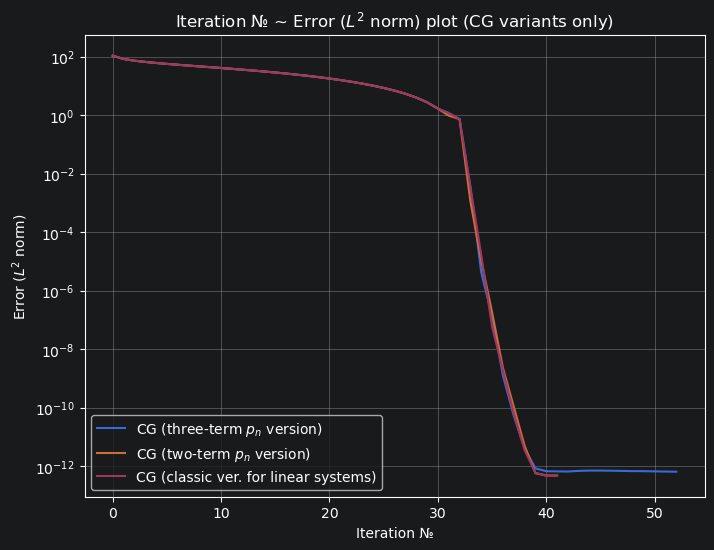

In [22]:
plt.figure(figsize=(8,6))
plt.xlabel("Iteration №")
plt.ylabel("Error ($L^2$ norm)")
plt.grid(True)
plt.semilogy(errors_cg, label='CG (three-term $p_n$ version)')
plt.semilogy(errors_cg_two, label='CG (two-term $p_n$ version)')
plt.semilogy(errors_cg_classic, label='CG (classic ver. for linear systems)')
plt.title("Iteration № ~ Error ($L^2$ norm) plot (CG variants only)")
plt.legend()
plt.show()